   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

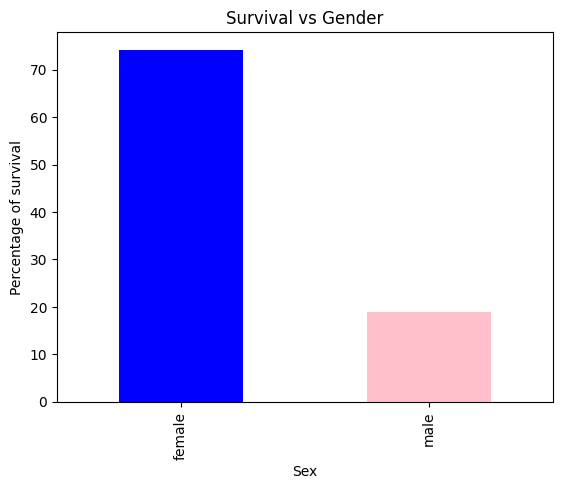

/tmp/ipython-input-768971702.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100


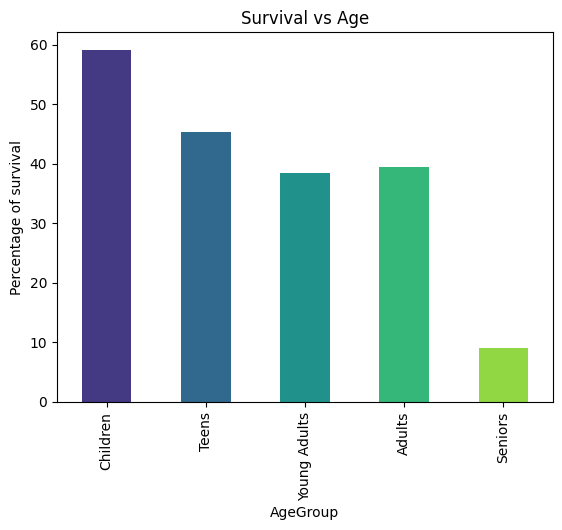

/tmp/ipython-input-768971702.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_fare = df.groupby('FareGroup')['Survived'].mean() * 100
/tmp/ipython-input-768971702.py:102: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  survival_table = df.pivot_table( index='FareGroup', columns='AgeGroup', values='Survived', aggfunc='mean')


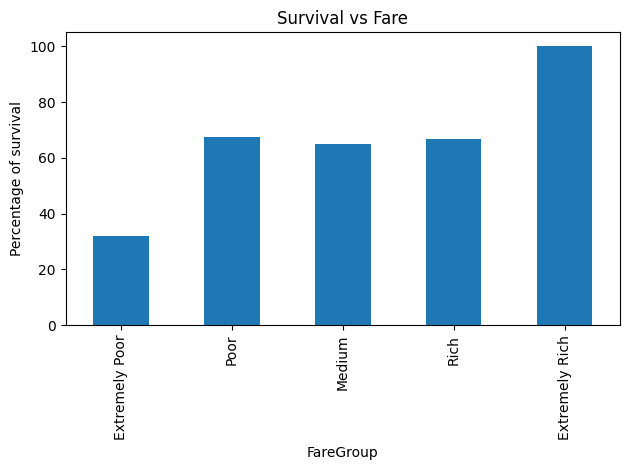

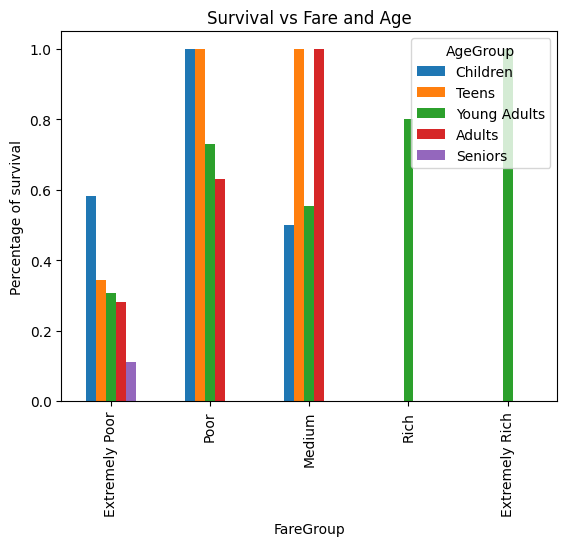

<Figure size 640x480 with 0 Axes>

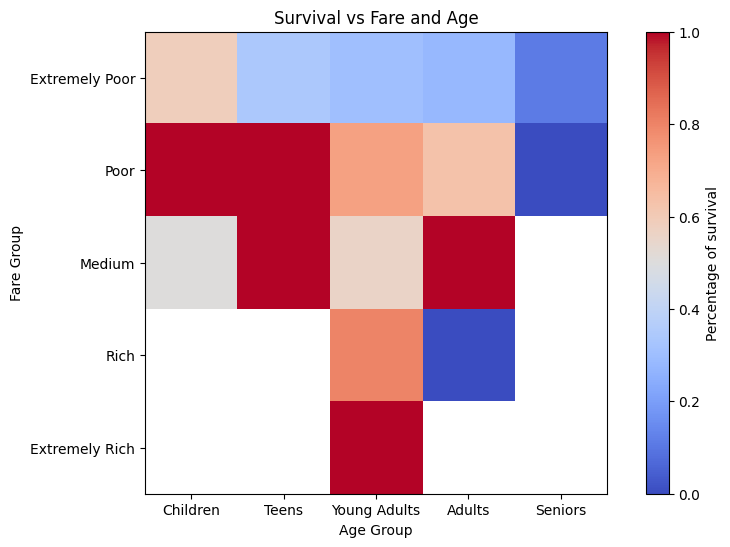

/tmp/ipython-input-768971702.py:122: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  male_table = df[df['Sex'] == 'male'].pivot_table( index='FareGroup', columns='AgeGroup', values='Survived', aggfunc='mean')
/tmp/ipython-input-768971702.py:123: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  female_table = df[df['Sex'] == 'female'].pivot_table( index='FareGroup', columns='AgeGroup', values='Survived', aggfunc='mean')


<Figure size 640x480 with 0 Axes>

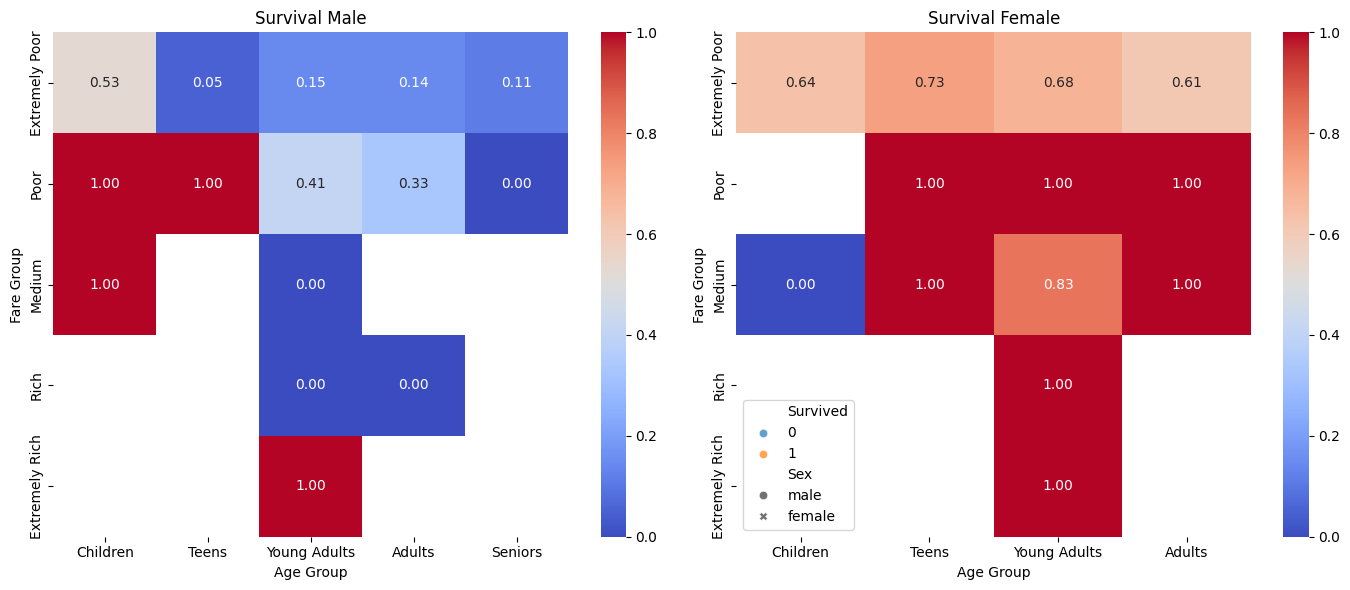

<Figure size 640x480 with 0 Axes>

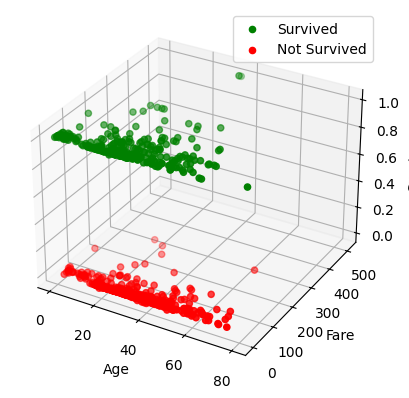

<Figure size 640x480 with 0 Axes>

In [33]:

"""Titanic Data Analysis and Visualization
---------------------------------------
This script performs exploratory data analysis on the Titanic dataset,
using pandas, seaborn, and matplotlib for data processing and visualization.

Features:
- Basic statistics
- Survival rate by gender, age, and fare
- Heatmaps and 3D visualization
"""

#NumPy module for numeric arrays renamed np
import numpy as np

#Pandas module for data processing csv, statistics, filter etc. renamed pd
import pandas as pd

#Matplotlib basic 2D vicualization maybe harder on demanding plots
import matplotlib.pyplot as plt

#Ready scatter plots, histos, boxplots, violin plots, heatmaps
import seaborn as sns

#mpl_toolkits.mplot3d module that allows 3D representation, Axes3D class for 3D axis
from mpl_toolkits.mplot3d import Axes3D


from matplotlib.colors import ListedColormap, BoundaryNorm

import matplotlib.patches as mpatches

#Download and Read a CSV df stands for data frame
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

#Show the first 5 rows
print(df.head())

#Show the last 5 rows
print(df.tail())

#Show info
print(df.info())

#Show statistics numeric
print(df.describe())

#Show statistics for all parts adds frequency, unique etc.
df.describe(include='all')

# Find mean valuse of a column of numbers
print("Mean age:", df['Age'].mean())

# Find the percent of men to women from a column with strings
print(df['Sex'].value_counts(normalize=True)*100)

#Mean percentage of a numeric column
print("Survived: ",df['Survived'].mean()*100, "%")

#Percentage of two 2 grouped categories
print(df.groupby('Sex')['Survived'].mean()*100)

#Filter numerical
print("Non Adults: ", df[df['Age'] < 18])

#Filter string and number
women_survived = df[(df['Sex'] == 'female') & (df['Survived'] == 1)]
male_notsurvived = df[(df['Sex'] == 'male') & (df['Survived'] == 0)]

print(women_survived)
print(male_notsurvived)

#Plot a bar graph for percentage survival by gender
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
survival_by_sex.plot(kind='bar', color=['blue', 'pink'])
plt.title("Survival vs Gender")
plt.ylabel("Percentage of survival")
plt.show()

plt.tight_layout()

#Plot a bar graph for percentage survival by age
df['AgeGroup'] = pd.cut(df['Age'], bins= [0, 14, 18, 40, 65, 100], labels= ['Children', 'Teens', 'Young Adults', 'Adults', 'Seniors'], right=False)

survival_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
survival_by_age.plot(kind='bar',color=sns.color_palette("viridis",len(survival_by_age)),)
plt.title("Survival vs Age")
plt.ylabel("Percentage of survival")
plt.show()
plt.tight_layout()

#Plot a for the propability of age and fare
df['FareGroup'] = pd.cut(df['Fare'], bins= [0, 50, 150, 250, 350, 550], labels= ['Extremely Poor', 'Poor', 'Medium', 'Rich', 'Extremely Rich'], right=False)

survival_by_fare = df.groupby('FareGroup')['Survived'].mean() * 100
survival_by_fare.plot(kind='bar')
plt.title("Survival vs Fare")
plt.ylabel("Percentage of survival")
plt.tight_layout()


#Plot the propability of survivability per fare per age
survival_table = df.pivot_table( index='FareGroup', columns='AgeGroup', values='Survived', aggfunc='mean')
survival_table.plot(kind='bar')
plt.title("Survival vs Fare and Age")
plt.ylabel("Percentage of survival")
plt.show()
plt.tight_layout()

plt.figure(figsize=(10, 6))
plt.imshow(survival_table, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Percentage of survival')
plt.title("Survival vs Fare and Age")
plt.xlabel("Age Group")
plt.ylabel("Fare Group")
plt.xticks(range(len(survival_table.columns)), survival_table.columns)
plt.yticks(range(len(survival_table.index)), survival_table.index)
plt.show()
plt.tight_layout()


#Plot HEATMAPS for the propability of survival per fare per age per sex
male_table = df[df['Sex'] == 'male'].pivot_table( index='FareGroup', columns='AgeGroup', values='Survived', aggfunc='mean')
female_table = df[df['Sex'] == 'female'].pivot_table( index='FareGroup', columns='AgeGroup', values='Survived', aggfunc='mean')

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(male_table, cmap='coolwarm', annot=True, fmt=".2f", ax=axs[0])
axs[0].set_title('Survival Male')
axs[0].set_xlabel('Age Group')
axs[0].set_ylabel('Fare Group')

sns.heatmap(female_table, cmap='coolwarm', annot=True, fmt=".2f", ax=axs[1])
axs[1].set_title('Survival Female')
axs[1].set_xlabel('Age Group')
axs[1].set_ylabel('Fare Group')
plt.tight_layout()

#SCATTER PLOT
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', alpha=0.7, data=df)
plt.show()
plt.tight_layout()

#3D plot wit matlib for survivability per age per fare
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

survived = df[df['Survived']==1]
not_survived = df[df['Survived']==0]
ax.scatter(survived['Age'], survived['Fare'], survived['Survived'], c='green', label='Survived')
ax.scatter(not_survived['Age'], not_survived['Fare'], not_survived['Survived'], c='red', label='Not Survived')

ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_zlabel('Survived')

ax.legend()
plt.show()
plt.tight_layout()




